In [1]:
import random
import networkx as nx
import torch
from torch_geometric.data import Data, Dataset

In [5]:
def generate_watts_strogatz(n_nodes, with_label=False):
    """
    Watts-Strogatz small-world graph.
    - k: number of nearest neighbours to connect (even integer)
    - p: rewiring probability in [0, 1]
    """
    k = random.choice([4, 6, 8])
    p = random.uniform(0.0, 1.0)
    G = nx.watts_strogatz_graph(n=n_nodes, k=k, p=p)

    if with_label == True:
        return G, p, k
    else:
        return G


def generate_barabasi_albert(n_nodes, with_label=False):
    """
    Barabási-Albert scale-free graph.
    - m: number of edges to attach from a new node to existing nodes
    """
    m = random.randint(1, 5)
    G = nx.barabasi_albert_graph(n=n_nodes, m=m)

    if with_label == True:
        return G, m
    else:
        return G


def generate_random_regular(n_nodes, with_label=False):
    """
    Random regular graph where every node has degree d.
    Requires d * n_nodes to be even.
    """
    d = random.randint(2, min(10, n_nodes - 1))
    if (d * n_nodes) % 2 != 0:
        d = d + 1 if d + 1 < n_nodes else d - 1

    G = nx.random_regular_graph(d=d, n=n_nodes)

    if with_label == True:
        return G, d
    else:
        return G

Example of how a Dataset can be created:

In [6]:
class WattsStrogatzDataset(Dataset):
    """
    Each item is a Watts-Strogatz small-world graph with randomly sampled
    parameters (k, p). The label `y` is the rewiring probability p in [0, 1].
    """
    def __init__(self, dataset_size, n_nodes):
        self.dataset_size = dataset_size
        self.n_nodes = n_nodes

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):

        G, p, k = generate_watts_strogatz(self.n_nodes, with_label=True)

        # get the adjacency matrix from the nx graph
        A = nx.adjacency_matrix(G).todense()
        A = torch.from_numpy(A) * 1.0

        # get the edge indices from the adjacency matrix
        edge_index = A.nonzero(as_tuple=False).T

        # Create the graph data object
        graph = Data(
            edge_index=edge_index, 
            y=[p],
        )

        return graph

ws_dataset = WattsStrogatzDataset(
    dataset_size=200,
    n_nodes=100,
)

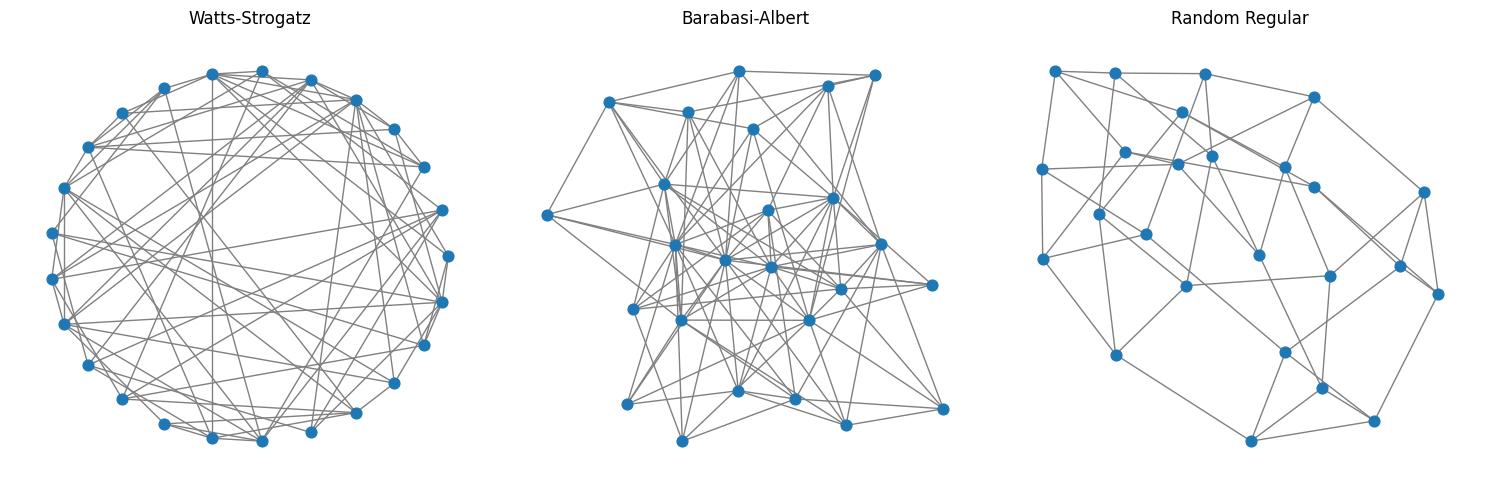

In [7]:
import matplotlib.pyplot as plt
from pygsp import graphs

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

num_nodes = 25

G = generate_watts_strogatz(num_nodes)
pos = graphs.Ring(N = num_nodes).coords
nx.draw(G, pos, ax=axs[0], node_size=60,
            edge_color="gray", with_labels=False)
axs[0].set_title("Watts-Strogatz")

G = generate_barabasi_albert(num_nodes)
pos = nx.spring_layout(G)
nx.draw(G, pos, ax=axs[1], node_size=60,
            edge_color="gray", with_labels=False)
axs[1].set_title("Barabasi-Albert")

G = generate_random_regular(num_nodes)
pos = nx.spring_layout(G)
nx.draw(G, pos, ax=axs[2], node_size=60,
            edge_color="gray", with_labels=False)
axs[2].set_title("Random Regular")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np


#May want to use Scipy Sparse Arrays for large graphs
print(nx.convert_matrix.to_numpy_array(G))

[[0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
  0.]
 [1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
  0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  1.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.

In [17]:
import random
import torch
import networkx as nx
from torch.utils.data import Dataset
from torch_geometric.data import Data

class GraphFamilyDataset(Dataset):
    """
    Balanced graph classification dataset over:

        0 -> Watts-Strogatz
        1 -> Barabasi-Albert
        2 -> Random Regular

    Each graph is converted directly to sparse edge_index.

    Node features:
        - normalized degree
        - clustering coefficient

    Optional graph statistics are also stored.
    """

    def __init__(self, dataset_size, n_nodes):
        self.dataset_size = dataset_size
        self.n_nodes = n_nodes

        self.generators = [
            generate_watts_strogatz,
            generate_barabasi_albert,
            generate_random_regular,
        ]

        # -------- Balanced label assignment --------
        base_labels = [0, 1, 2] * (dataset_size // 3)
        remainder = [i for i in range(dataset_size % 3)]
        self.labels = base_labels + remainder
        random.shuffle(self.labels)

    def __len__(self):
        return self.dataset_size

    def graph_to_edge_index(self, G):
        edges = list(G.edges())

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

        # make undirected
        edge_index_rev = edge_index.flip(0)
        edge_index = torch.cat([edge_index, edge_index_rev], dim=1)

        return edge_index

    def compute_node_features(self, G):
        degrees = torch.tensor(
            [deg for _, deg in G.degree()],
            dtype=torch.float
        ).view(-1, 1)

        clustering = torch.tensor(
            [nx.clustering(G, node) for node in G.nodes()],
            dtype=torch.float
        ).view(-1, 1)

        degrees = degrees / degrees.max()

        x = torch.cat([degrees, clustering], dim=1)
        return x

    def compute_graph_features(self, G):
        avg_degree = sum(dict(G.degree()).values()) / self.n_nodes
        avg_clustering = nx.average_clustering(G)

        return torch.tensor(
            [avg_degree, avg_clustering],
            dtype=torch.float
        )

    def __getitem__(self, idx):

        label = self.labels[idx]
        generator_fn = self.generators[label]

        # generate graph
        G = generator_fn(self.n_nodes)

        # sparse edge list
        edge_index = self.graph_to_edge_index(G)

        # node structural features
        x = self.compute_node_features(G)

        # optional graph-level features
        graph_features = self.compute_graph_features(G)

        data = Data(
            x=x,
            edge_index=edge_index,
            y=torch.tensor(label, dtype=torch.long),
        )

        # attach extra graph-level metadata if useful later
        data.graph_features = graph_features

        return data

In [18]:
train = GraphFamilyDataset(100,50)

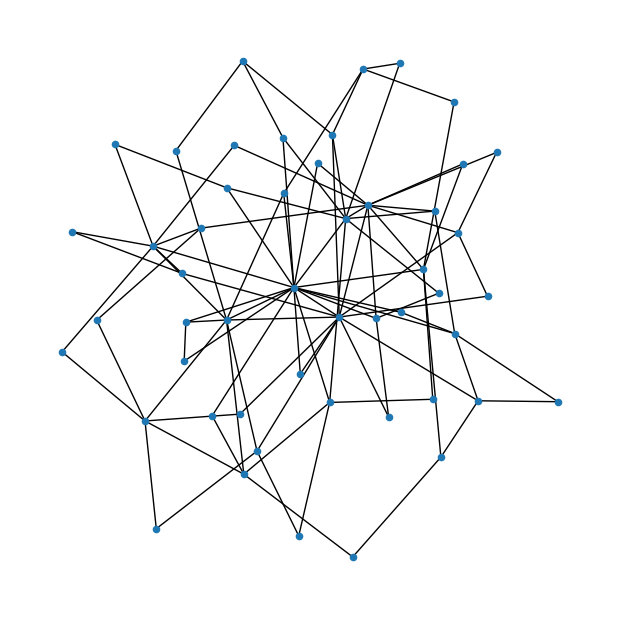

In [32]:
from torch_geometric.utils import to_networkx

sample = train[99]

G = to_networkx(sample, to_undirected=True)

plt.figure(figsize=(6,6))
nx.draw(
    G,
    node_size=20,
    with_labels=False
)
plt.show()